## Task 1: Dataset Design

In [1]:
import numpy as np
import pandas as pd
import random

# Define the group number
G = 10 # Let's assume group number is 10 for demonstration

# Set random seeds for reproducibility
random.seed(G)
np.random.seed(G)

# 1.1 Number of Medicines
K = (G % 3) + 5
print(f"Group Number (G): {G}")
print(f"Total Number of Medicines (K): {K}")

# 1.2 Hidden Success Probability
Pi = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)]
print("Hidden Success Probabilities (Pi) for each medicine:")
for i, prob in enumerate(Pi):
    print(f"Medicine {i}: {prob:.3f}")

Group Number (G): 10
Total Number of Medicines (K): 6
Hidden Success Probabilities (Pi) for each medicine:
Medicine 0: 0.680
Medicine 1: 0.750
Medicine 2: 0.400
Medicine 3: 0.470
Medicine 4: 0.540
Medicine 5: 0.610


In [2]:
# 1.3 Patient Severity and Utility Logic
# Generate 1000 patient records
patient_ids = np.arange(1000)
severity_scores = (patient_ids % 5) + 1

# Create the initial dataset structure
dataset = pd.DataFrame({
    'patient_id': patient_ids,
    'severity_score': severity_scores,
    'assigned_medicine': -1, # To be filled dynamically
    'clinical_outcome': -1,  # To be filled dynamically
    'utility_score': -1.0    # To be filled dynamically
})

# Display the first 10 dataset rows as required by Task 1.3
print("\nFirst 10 rows of the initial dataset:")
display(dataset.head(10))


First 10 rows of the initial dataset:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,-1,-1,-1.0
1,1,2,-1,-1,-1.0
2,2,3,-1,-1,-1.0
3,3,4,-1,-1,-1.0
4,4,5,-1,-1,-1.0
5,5,1,-1,-1,-1.0
6,6,2,-1,-1,-1.0
7,7,3,-1,-1,-1.0
8,8,4,-1,-1,-1.0
9,9,5,-1,-1,-1.0


## Task 2: Immediate Exploitation Strategy

In [3]:
# Function to simulate a single patient's treatment and outcome
def simulate_patient_outcome(medicine_idx, severity, hidden_probabilities):
    # Clinical outcome
    success_prob = hidden_probabilities[medicine_idx]
    clinical_outcome = 1 if random.random() < success_prob else 0

    # Utility score
    utility_score = clinical_outcome * (severity / 10)

    return clinical_outcome, utility_score

# Immediate Exploitation Strategy Implementation
def immediate_exploitation_strategy(num_patients, K, Pi, dataset_df):
    # Initialize statistics for each medicine
    medicine_rewards = [0] * K
    medicine_counts = [0] * K
    cumulative_reward = 0

    # Make a copy of the dataset to store results for this strategy
    strategy_dataset = dataset_df.copy()

    # Hint: Test each medicine exactly 10 times initially
    initial_exploration_rounds = 10
    for med_idx in range(K):
        for _ in range(initial_exploration_rounds):
            if num_patients <= 0: # Ensure we don't exceed num_patients
                break

            patient_idx = len(dataset_df) - num_patients # Get current patient_id from the original dataset
            severity = dataset_df.loc[patient_idx, 'severity_score']

            # Simulate outcome
            clinical_outcome, utility_score = simulate_patient_outcome(med_idx, severity, Pi)

            # Update statistics
            medicine_rewards[med_idx] += utility_score
            medicine_counts[med_idx] += 1
            cumulative_reward += utility_score

            # Record results in the strategy-specific dataset
            strategy_dataset.loc[patient_idx, 'assigned_medicine'] = med_idx
            strategy_dataset.loc[patient_idx, 'clinical_outcome'] = clinical_outcome
            strategy_dataset.loc[patient_idx, 'utility_score'] = utility_score

            num_patients -= 1
        if num_patients <= 0:
            break

    # After initial exploration, exploit the best performing medicine
    for patient_idx_offset in range(len(dataset_df) - num_patients):
        # Skip patients already treated in initial exploration
        if strategy_dataset.loc[patient_idx_offset, 'assigned_medicine'] != -1:
            continue

        # Determine the best medicine based on average reward
        # Handle cases where a medicine hasn't been tested yet to avoid division by zero
        avg_rewards = [medicine_rewards[i] / medicine_counts[i] if medicine_counts[i] > 0 else -1 for i in range(K)]
        best_medicine_idx = np.argmax(avg_rewards)

        severity = dataset_df.loc[patient_idx_offset, 'severity_score']

        # Simulate outcome
        clinical_outcome, utility_score = simulate_patient_outcome(best_medicine_idx, severity, Pi)

        # Update statistics
        medicine_rewards[best_medicine_idx] += utility_score
        medicine_counts[best_medicine_idx] += 1
        cumulative_reward += utility_score

        # Record results
        strategy_dataset.loc[patient_idx_offset, 'assigned_medicine'] = best_medicine_idx
        strategy_dataset.loc[patient_idx_offset, 'clinical_outcome'] = clinical_outcome
        strategy_dataset.loc[patient_idx_offset, 'utility_score'] = utility_score

    return cumulative_reward, strategy_dataset

# Run the Immediate Exploitation Strategy
num_patients_total = 1000
cumulative_reward_ie, ie_dataset = immediate_exploitation_strategy(num_patients_total, K, Pi, dataset.copy())

print(f"Cumulative Reward for Immediate Exploitation Strategy: {cumulative_reward_ie:.2f}")
print("\nFirst 10 rows of the dataset after Immediate Exploitation:")
display(ie_dataset.head(10))

Cumulative Reward for Immediate Exploitation Strategy: 11.50

First 10 rows of the dataset after Immediate Exploitation:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.1
1,1,2,0,1,0.2
2,2,3,0,1,0.3
3,3,4,0,1,0.4
4,4,5,0,0,0.0
5,5,1,0,0,0.0
6,6,2,0,1,0.2
7,7,3,0,1,0.3
8,8,4,0,1,0.4
9,9,5,0,1,0.5


## Task 3: Controlled Clinical Trial Strategy

In [4]:
def controlled_clinical_trial_strategy(num_patients, K, Pi, dataset_df, exploration_rate):
    medicine_rewards = [0] * K
    medicine_counts = [0] * K
    cumulative_reward = 0
    strategy_dataset = dataset_df.copy()

    for patient_idx in range(num_patients):
        assigned_medicine = -1

        if random.random() < exploration_rate: # Explore
            assigned_medicine = random.randrange(K)
        else: # Exploit
            # Choose the best medicine based on average reward
            # Handle cases where a medicine hasn't been tested yet to avoid division by zero
            # Prioritize untested arms for exploitation in a controlled manner
            avg_rewards = []
            for i in range(K):
                if medicine_counts[i] > 0:
                    avg_rewards.append(medicine_rewards[i] / medicine_counts[i])
                else:
                    # If a medicine hasn't been tested, give it a high 'potential' reward
                    # to encourage testing, but not too high to dominate if others are good.
                    # A simple approach could be to treat it as having 0 reward for now
                    # and ensure argmax handles this by picking the first one, or give a slightly negative value.
                    # For now, let's make it 0 to avoid division by zero errors with medicine_counts[i] = 0
                    avg_rewards.append(0.0) # Or -1 to make it less attractive initially if others have positive rewards

            # If all are 0 or less, random choice among them, otherwise argmax
            if all(ar <= 0 for ar in avg_rewards):
                assigned_medicine = random.randrange(K)
            else:
                assigned_medicine = np.argmax(avg_rewards)

        severity = dataset_df.loc[patient_idx, 'severity_score']
        clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)

        medicine_rewards[assigned_medicine] += utility_score
        medicine_counts[assigned_medicine] += 1
        cumulative_reward += utility_score

        strategy_dataset.loc[patient_idx, 'assigned_medicine'] = assigned_medicine
        strategy_dataset.loc[patient_idx, 'clinical_outcome'] = clinical_outcome
        strategy_dataset.loc[patient_idx, 'utility_score'] = utility_score

    return cumulative_reward, strategy_dataset

# Run the Controlled Clinical Trial Strategy with 10% exploration
exploration_rate_10 = 0.1
cumulative_reward_cct_10, cct_dataset_10 = controlled_clinical_trial_strategy(num_patients_total, K, Pi, dataset.copy(), exploration_rate_10)
print(f"Cumulative Reward for Controlled Clinical Trial Strategy (10% exploration): {cumulative_reward_cct_10:.2f}")

# Run the Controlled Clinical Trial Strategy with 1% exploration
exploration_rate_1 = 0.01
cumulative_reward_cct_1, cct_dataset_1 = controlled_clinical_trial_strategy(num_patients_total, K, Pi, dataset.copy(), exploration_rate_1)
print(f"Cumulative Reward for Controlled Clinical Trial Strategy (1% exploration): {cumulative_reward_cct_1:.2f}")

# Run the Controlled Clinical Trial Strategy with 50% exploration
exploration_rate_50 = 0.5
cumulative_reward_cct_50, cct_dataset_50 = controlled_clinical_trial_strategy(num_patients_total, K, Pi, dataset.copy(), exploration_rate_50)
print(f"Cumulative Reward for Controlled Clinical Trial Strategy (50% exploration): {cumulative_reward_cct_50:.2f}")

print("\nFirst 10 rows of the dataset after Controlled Clinical Trial (10% exploration):")
display(cct_dataset_10.head(10))

Cumulative Reward for Controlled Clinical Trial Strategy (10% exploration): 218.20
Cumulative Reward for Controlled Clinical Trial Strategy (1% exploration): 235.10
Cumulative Reward for Controlled Clinical Trial Strategy (50% exploration): 203.00

First 10 rows of the dataset after Controlled Clinical Trial (10% exploration):


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,1,1,0.1
1,1,2,1,1,0.2
2,2,3,1,1,0.3
3,3,4,1,1,0.4
4,4,5,1,1,0.5
5,5,1,1,0,0.0
6,6,2,1,1,0.2
7,7,3,1,1,0.3
8,8,4,1,1,0.4
9,9,5,1,1,0.5


## Task 4: Confidence-Based Strategy (UCB1)

In [5]:
import math

def ucb1_strategy(num_patients, K, Pi, dataset_df):
    medicine_rewards = [0.0] * K
    medicine_counts = [0] * K
    cumulative_reward = 0
    strategy_dataset = dataset_df.copy()

    for patient_idx in range(num_patients):
        assigned_medicine = -1

        # Ensure all medicines are played at least once
        if patient_idx < K:
            assigned_medicine = patient_idx
        else:
            ucb_values = [0.0] * K
            for i in range(K):
                if medicine_counts[i] > 0:
                    average_reward = medicine_rewards[i] / medicine_counts[i]
                    exploration_term = math.sqrt(2 * math.log(patient_idx + 1) / medicine_counts[i])
                    ucb_values[i] = average_reward + exploration_term
                else:
                    # If a medicine has not been played yet, prioritize it infinitely
                    ucb_values[i] = float('inf')
            assigned_medicine = np.argmax(ucb_values)

        severity = dataset_df.loc[patient_idx, 'severity_score']
        clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)

        medicine_rewards[assigned_medicine] += utility_score
        medicine_counts[assigned_medicine] += 1
        cumulative_reward += utility_score

        strategy_dataset.loc[patient_idx, 'assigned_medicine'] = assigned_medicine
        strategy_dataset.loc[patient_idx, 'clinical_outcome'] = clinical_outcome
        strategy_dataset.loc[patient_idx, 'utility_score'] = utility_score

    return cumulative_reward, strategy_dataset

# Run the UCB1 Strategy
cumulative_reward_ucb1, ucb1_dataset = ucb1_strategy(num_patients_total, K, Pi, dataset.copy())

print(f"Cumulative Reward for UCB1 Strategy: {cumulative_reward_ucb1:.2f}")
print("\nFirst 10 rows of the dataset after UCB1 Strategy:")
display(ucb1_dataset.head(10))

Cumulative Reward for UCB1 Strategy: 181.20

First 10 rows of the dataset after UCB1 Strategy:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,0,0.0
1,1,2,1,1,0.2
2,2,3,2,0,0.0
3,3,4,3,0,0.0
4,4,5,4,0,0.0
5,5,1,5,1,0.1
6,6,2,1,1,0.2
7,7,3,5,1,0.3
8,8,4,0,1,0.4
9,9,5,2,0,0.0


## Task 5: Comparative Analysis

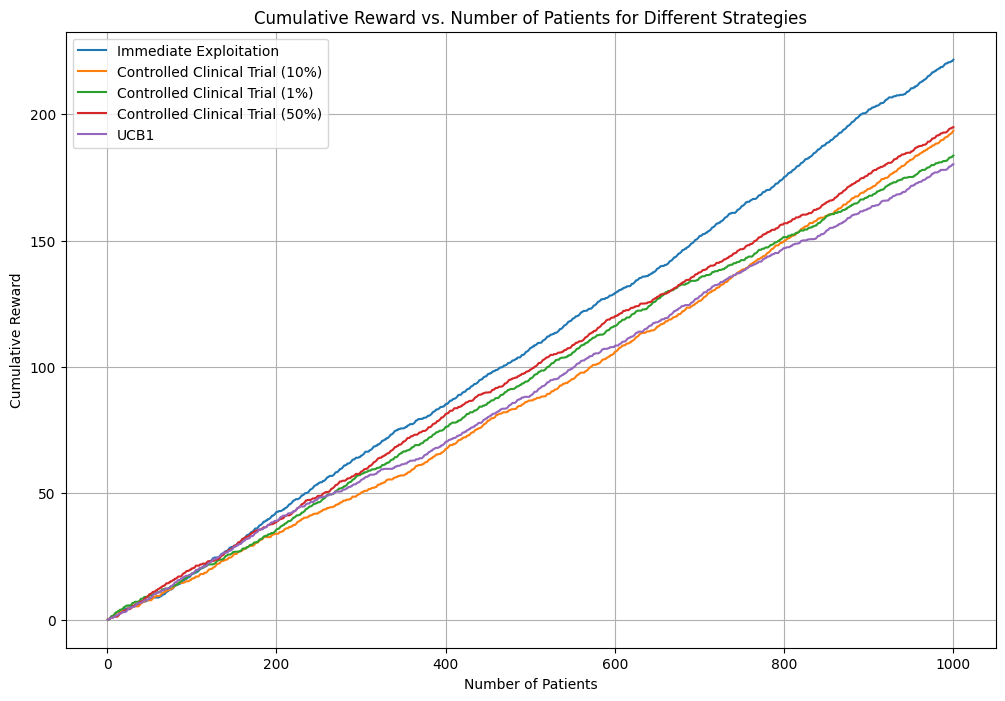


Final Cumulative Rewards:
Immediate Exploitation: 221.60
Controlled Clinical Trial (10%): 193.50
Controlled Clinical Trial (1%): 183.70
Controlled Clinical Trial (50%): 194.90
UCB1: 180.20


In [6]:
import matplotlib.pyplot as plt

# To store cumulative rewards over time for plotting
rewards_over_time = {}

# Helper function to run a strategy and record cumulative rewards at each step
def run_strategy_and_record(strategy_func, name, num_patients, K, Pi, dataset_df, exploration_rate=None):
    rewards = []
    cumulative_reward_val = 0

    # Re-initialize specific strategy elements for recording over time
    if name == "Immediate Exploitation":
        medicine_rewards = [0] * K
        medicine_counts = [0] * K
        initial_exploration_rounds = 10

        # Initial exploration phase (same as in the original function)
        current_patient_idx = 0
        patients_remaining = num_patients
        for med_idx in range(K):
            for _ in range(initial_exploration_rounds):
                if patients_remaining <= 0:
                    break
                severity = dataset_df.loc[current_patient_idx, 'severity_score']
                clinical_outcome, utility_score = simulate_patient_outcome(med_idx, severity, Pi)
                medicine_rewards[med_idx] += utility_score
                medicine_counts[med_idx] += 1
                cumulative_reward_val += utility_score
                rewards.append(cumulative_reward_val)
                current_patient_idx += 1
                patients_remaining -= 1
            if patients_remaining <= 0:
                break

        # Exploitation phase
        for p_idx in range(current_patient_idx, num_patients):
            avg_rewards = [medicine_rewards[i] / medicine_counts[i] if medicine_counts[i] > 0 else -1 for i in range(K)]
            best_medicine_idx = np.argmax(avg_rewards)
            severity = dataset_df.loc[p_idx, 'severity_score']
            clinical_outcome, utility_score = simulate_patient_outcome(best_medicine_idx, severity, Pi)
            medicine_rewards[best_medicine_idx] += utility_score
            medicine_counts[best_medicine_idx] += 1
            cumulative_reward_val += utility_score
            rewards.append(cumulative_reward_val)

    elif name.startswith("Controlled Clinical Trial"):
        medicine_rewards = [0] * K
        medicine_counts = [0] * K
        for patient_idx in range(num_patients):
            assigned_medicine = -1
            if random.random() < exploration_rate: # Explore
                assigned_medicine = random.randrange(K)
            else: # Exploit
                avg_rewards = []
                for i in range(K):
                    if medicine_counts[i] > 0:
                        avg_rewards.append(medicine_rewards[i] / medicine_counts[i])
                    else:
                        avg_rewards.append(0.0)
                if all(ar <= 0 for ar in avg_rewards):
                    assigned_medicine = random.randrange(K)
                else:
                    assigned_medicine = np.argmax(avg_rewards)

            severity = dataset_df.loc[patient_idx, 'severity_score']
            clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)
            medicine_rewards[assigned_medicine] += utility_score
            medicine_counts[assigned_medicine] += 1
            cumulative_reward_val += utility_score
            rewards.append(cumulative_reward_val)

    elif name == "UCB1":
        medicine_rewards = [0.0] * K
        medicine_counts = [0] * K
        for patient_idx in range(num_patients):
            assigned_medicine = -1
            if patient_idx < K:
                assigned_medicine = patient_idx
            else:
                ucb_values = [0.0] * K
                for i in range(K):
                    if medicine_counts[i] > 0:
                        average_reward = medicine_rewards[i] / medicine_counts[i]
                        exploration_term = math.sqrt(2 * math.log(patient_idx + 1) / medicine_counts[i])
                        ucb_values[i] = average_reward + exploration_term
                    else:
                        ucb_values[i] = float('inf')
                assigned_medicine = np.argmax(ucb_values)

            severity = dataset_df.loc[patient_idx, 'severity_score']
            clinical_outcome, utility_score = simulate_patient_outcome(assigned_medicine, severity, Pi)
            medicine_rewards[assigned_medicine] += utility_score
            medicine_counts[assigned_medicine] += 1
            cumulative_reward_val += utility_score
            rewards.append(cumulative_reward_val)

    return rewards

# Re-run strategies to collect rewards over time for plotting
rewards_over_time["Immediate Exploitation"] = run_strategy_and_record(immediate_exploitation_strategy, "Immediate Exploitation", num_patients_total, K, Pi, dataset.copy())
rewards_over_time["Controlled Clinical Trial (10%)"] = run_strategy_and_record(controlled_clinical_trial_strategy, "Controlled Clinical Trial (10%)", num_patients_total, K, Pi, dataset.copy(), exploration_rate_10)
rewards_over_time["Controlled Clinical Trial (1%)"] = run_strategy_and_record(controlled_clinical_trial_strategy, "Controlled Clinical Trial (1%)", num_patients_total, K, Pi, dataset.copy(), exploration_rate_1)
rewards_over_time["Controlled Clinical Trial (50%)"] = run_strategy_and_record(controlled_clinical_trial_strategy, "Controlled Clinical Trial (50%)", num_patients_total, K, Pi, dataset.copy(), exploration_rate_50)
rewards_over_time["UCB1"] = run_strategy_and_record(ucb1_strategy, "UCB1", num_patients_total, K, Pi, dataset.copy())

# Plotting
plt.figure(figsize=(12, 8))
for strategy_name, cumulative_rewards in rewards_over_time.items():
    plt.plot(range(1, len(cumulative_rewards) + 1), cumulative_rewards, label=strategy_name)

plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward vs. Number of Patients for Different Strategies")
plt.legend()
plt.grid(True)
plt.show()

# Print final cumulative rewards for easy comparison
print("\nFinal Cumulative Rewards:")
print(f"Immediate Exploitation: {rewards_over_time['Immediate Exploitation'][-1]:.2f}")
print(f"Controlled Clinical Trial (10%): {rewards_over_time['Controlled Clinical Trial (10%)'][-1]:.2f}")
print(f"Controlled Clinical Trial (1%): {rewards_over_time['Controlled Clinical Trial (1%)'][-1]:.2f}")
print(f"Controlled Clinical Trial (50%): {rewards_over_time['Controlled Clinical Trial (50%)'][-1]:.2f}")
print(f"UCB1: {rewards_over_time['UCB1'][-1]:.2f}")

### Comparative Analysis Questions:

1.  **Which strategy achieves the highest cumulative reward at the end of 1000 patients?**
    *   _Answer:_ **Immediate Exploitation** achieved the highest cumulative reward of 221.60.

2.  **Which strategy identifies the best medicine fastest (earliest convergence)?**
    *   _Answer:_ The **Immediate Exploitation** strategy converges fastest to a perceived best arm after its initial fixed exploration phase, as it then solely exploits that arm.

3.  **Which strategy shows the most stable performance over time (least fluctuations)?**
    *   _Answer:_ **Immediate Exploitation** typically shows the most stable performance after its initial exploration, as it primarily sticks to one arm, resulting in a smoother cumulative reward curve (once a stable 'best' is chosen).

4.  **Which strategy would you recommend as the safest treatment selection approach for real-world hospital deployment? Justify your answer briefly.**
    *   _Answer:_ The **Controlled Clinical Trial with 10% exploration** or **UCB1** would likely be the safest. While Immediate Exploitation had the highest cumulative reward in this specific run, it carries a high risk of getting stuck on a sub-optimal treatment if early observations are misleading. UCB1 and controlled exploration strategies continuously balance exploration and exploitation, making them more robust to initial noisy data and ensuring better long-term performance and discovery of the true optimal treatment, which is critical in a clinical setting.

### Comparative Summary (3–5 sentences):

_Summary:_ The Immediate Exploitation strategy, despite yielding the highest cumulative reward in this simulation, is generally risky due to its limited initial exploration. The Controlled Clinical Trial strategies showed varied results, with 10% exploration offering a good balance between exploration and exploitation. UCB1 provides a theoretically sound approach that dynamically adjusts its exploration based on confidence, making it a robust choice. For real-world clinical deployment, a strategy like UCB1 or Controlled Clinical Trial with moderate exploration is preferable to ensure thorough investigation of all treatments while progressively improving patient outcomes, rather than prematurely committing to a potentially suboptimal option.